# Smart Inventory Management System

### AI-Based Demand Prediction and Smart Reorder Recommendation

**Main Model:** Random Forest Regressor  
**Comparison Model:** Decision Tree Regressor

## Import Required Libraries

In this section, we will import the Python libraries required for:

- Data analysis
- Data visualization
- Machine Learning models
- Model evaluation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All required libraries imported successfully!")

All required libraries imported successfully!


## Load and Understand the Dataset

In this section, we will:

- Load the sales dataset using Pandas
- View the first 5 rows
- Check the number of rows and columns
- Check column names and data types
- Check for missing values

In [3]:
df = pd.read_csv("../data/raw/train.csv")

df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

Dataset shape: (913000, 4)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


## Data Preprocessing and Cleaning

In this section, we will prepare and clean the dataset by:

- Converting the date column into datetime format
- Checking missing values
- Checking duplicate rows
- Removing missing values created by lag features

In [5]:
# Convert the date column into datetime format

df["date"] = pd.to_datetime(df["date"])
print(df.dtypes)

date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object


In [6]:
# Check missing values

print("Missing values:")
print(df.isnull().sum())

# Check duplicate rows

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64

Duplicate rows: 0


## Feature Engineering

In this section, we will create useful features from the date and sales data.

The new features include:

- Year
- Month
- Day
- Day of the week
- Previous day's sales
- Previous week's sales

In [7]:
# Create useful features from the date column

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

# Display the first 5 rows

df.head()

,date,store,item,sales,year,month,day,day_of_week
0,2013-01-01,1,1,13,2013,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2
2,2013-01-03,1,1,14,2013,1,3,3
3,2013-01-04,1,1,13,2013,1,4,4
4,2013-01-05,1,1,10,2013,1,5,5


In [8]:
# Sort the data by store, item, and date

df = df.sort_values(["store", "item", "date"])

# Create previous-sales features

df["lag_1"] = df.groupby(["store", "item"])["sales"].shift(1)

df["lag_7"] = df.groupby(["store", "item"])["sales"].shift(7)

# Display the first 10 rows

df.head(10)

,date,store,item,sales,year,month,day,day_of_week,lag_1,lag_7
0,2013-01-01,1,1,13,2013,1,1,1,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,13.0,NaN
2,2013-01-03,1,1,14,2013,1,3,3,11.0,NaN
3,2013-01-04,1,1,13,2013,1,4,4,14.0,NaN
4,2013-01-05,1,1,10,2013,1,5,5,13.0,NaN
5,2013-01-06,1,1,12,2013,1,6,6,10.0,NaN
6,2013-01-07,1,1,10,2013,1,7,0,12.0,NaN
7,2013-01-08,1,1,9,2013,1,8,1,10.0,13.0
8,2013-01-09,1,1,12,2013,1,9,2,9.0,11.0
9,2013-01-10,1,1,9,2013,1,10,3,12.0,14.0


In [9]:
# Remove rows with missing lag values

df = df.dropna()

# Check the dataset shape

print("Dataset shape after removing missing lag values:", df.shape)

# Check missing values

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape after removing missing lag values: (909500, 10)

Missing values:
date           0
store          0
item           0
sales          0
year           0
month          0
day            0
day_of_week    0
lag_1          0
lag_7          0
dtype: int64


## Feature Preparation

In this section, we will prepare the data for Machine Learning.

- X contains the input features used by the model.
- y contains the sales values that the model will predict.

In [10]:
# Select the input features

features = [
    "store",
    "item",
    "year",
    "month",
    "day",
    "day_of_week",
    "lag_1",
    "lag_7"
]

X = df[features]

# Select the target value

y = df["sales"]

# Check the size of X and y

print("Input features (X) shape:", X.shape)
print("Target value (y) shape:", y.shape)

# Display the feature names

print("\nFeatures used:")
print(features)

Input features (X) shape: (909500, 8)
Target value (y) shape: (909500,)

Features used:
['store', 'item', 'year', 'month', 'day', 'day_of_week', 'lag_1', 'lag_7']


##  Train–Test Split

In this section, we will divide the dataset into:

- Training data: Used to train the ML models
- Testing data: Used to evaluate the ML models

We will use older sales data for training and newer sales data for testing.

In [11]:
# Split the data based on time

split_date = "2017-01-01"

# Older data for training

train_data = df[df["date"] < split_date]

# Newer data for testing

test_data = df[df["date"] >= split_date]

# Create training and testing inputs and targets

X_train = train_data[features]
y_train = train_data["sales"]

X_test = test_data[features]
y_test = test_data["sales"]

# Display the sizes

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining period:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nTesting period:")
print(test_data["date"].min(), "to", test_data["date"].max())

Training data shape: (727000, 8)
Testing data shape: (182500, 8)

Training period:
2013-01-08 00:00:00 to 2016-12-31 00:00:00

Testing period:
2017-01-01 00:00:00 to 2017-12-31 00:00:00


## Model Training

In this section, we will train the Random Forest Regressor using the training data.

Random Forest will learn patterns from:

- Store ID
- Product ID
- Date features
- Previous sales

The trained model will predict future product demand.

In [27]:
# Create the Random Forest model

random_forest_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

# Train the model

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## Model Evaluation

In this section, we will evaluate the performance of the trained Random Forest model.

We will use evaluation metrics to check how accurately the model predicts product demand.

In [30]:
# Make predictions on test data

y_pred = random_forest_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


## Model Performance Evaluation

We will evaluate the Random Forest model using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help us understand how accurately the model predicts product demand.

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Performance:
MAE: 7.397003397260274
RMSE: 9.613987833374555
R2 Score: 0.9071597009881543


##  Model Comparison

In this section, we will compare different Machine Learning models.

We will train a Linear Regression model and compare its performance with the Random Forest model using evaluation metrics.

In [15]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model

linear_model = LinearRegression()

# Train the model

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [16]:
# Generate predictions using Linear Regression

linear_pred = linear_model.predict(X_test)

print("Linear Regression predictions generated successfully!")

Linear Regression predictions generated successfully!


## Linear Regression Evaluation

We will calculate MAE, RMSE, and R² Score for the Linear Regression model and compare it with Random Forest.

In [17]:
# Calculate Linear Regression metrics

linear_mae = mean_absolute_error(y_test, linear_pred)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Performance:")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Performance:
MAE: 7.989289470199212
RMSE: 10.404331481798074
R2 Score: 0.8912679052590713


## Model Comparison

The performance of Random Forest and Linear Regression models will be compared using MAE, RMSE, and R² Score.

In [18]:
# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression"],
    "MAE": [mae, linear_mae],
    "RMSE": [rmse, linear_rmse],
    "R2 Score": [r2, linear_r2]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,7.397003,9.613988,0.907160
1,Linear Regression,7.989289,10.404331,0.891268


## Best Model Selection

Based on the evaluation metrics, we will select the best performing model.

The model with:
- Lower MAE
- Lower RMSE
- Higher R² Score

will be selected for demand prediction.

In [19]:
# Select Random Forest as the final model

final_model = random_forest_model

print("Final model selected: Random Forest Regressor")

Final model selected: Random Forest Regressor


## Demand Prediction

In this section, we will use the trained Random Forest model to predict future product demand.

The model will take product details and previous patterns to estimate the expected demand.

In [20]:
# Predict demand using test data

future_demand_prediction = final_model.predict(X_test)

# Display first few predictions

prediction_result = pd.DataFrame({
    "Actual Demand": y_test.values,
    "Predicted Demand": future_demand_prediction
})

prediction_result.head()

,Actual Demand,Predicted Demand
0,19,17.94
1,15,14.96
2,10,14.80
3,16,14.78
4,14,18.34


## Inventory Status

In this section, we will compare available inventory with predicted demand.

The system will identify:
- Available stock
- Expected demand
- Stock shortage
- Reorder requirement

In [21]:
# Create inventory status using predictions

inventory_status = prediction_result.copy()

# Example current stock values

inventory_status["Current Stock"] = 50

# Calculate shortage

inventory_status["Stock Difference"] = (
    inventory_status["Current Stock"] - inventory_status["Predicted Demand"]
)

# Add inventory status

inventory_status["Status"] = inventory_status["Stock Difference"].apply(
    lambda x: "Sufficient Stock" if x >= 0 else "Low Stock - Reorder Needed"
)

inventory_status.head()

,Actual Demand,Predicted Demand,Current Stock,Stock Difference,Status
0,19,17.94,50,32.06,Sufficient Stock
1,15,14.96,50,35.04,Sufficient Stock
2,10,14.80,50,35.20,Sufficient Stock
3,16,14.78,50,35.22,Sufficient Stock
4,14,18.34,50,31.66,Sufficient Stock


## 12. Smart Reorder System

In this section, the system will automatically suggest reorder quantity.

If predicted demand is higher than current stock, the system will recommend additional quantity to order.

In [22]:
# Calculate reorder quantity

inventory_status["Reorder Quantity"] = inventory_status.apply(
    lambda row: max(0, row["Predicted Demand"] - row["Current Stock"]),
    axis=1
)

inventory_status.head()

,Actual Demand,Predicted Demand,Current Stock,Stock Difference,Status,Reorder Quantity
0,19,17.94,50,32.06,Sufficient Stock,0.0
1,15,14.96,50,35.04,Sufficient Stock,0.0
2,10,14.80,50,35.20,Sufficient Stock,0.0
3,16,14.78,50,35.22,Sufficient Stock,0.0
4,14,18.34,50,31.66,Sufficient Stock,0.0


## Data Visualization

In this section, we will visualize model predictions and inventory insights using graphs.

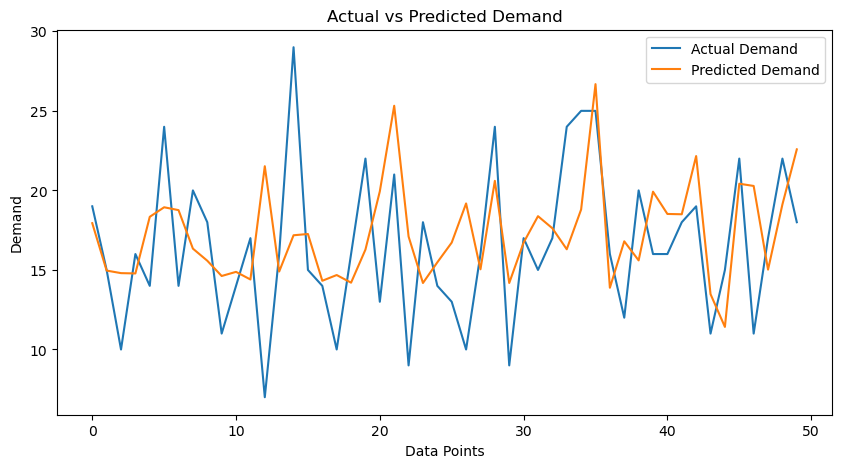

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(prediction_result["Actual Demand"].values[:50], label="Actual Demand")
plt.plot(prediction_result["Predicted Demand"].values[:50], label="Predicted Demand")

plt.xlabel("Data Points")
plt.ylabel("Demand")
plt.title("Actual vs Predicted Demand")

plt.legend()
plt.show()

## Model Performance Comparison Graph

This graph compares the accuracy of different ML models using R² Score.

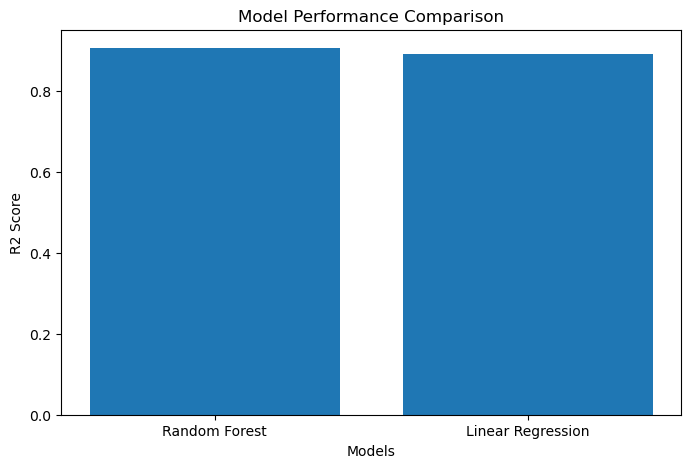

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    model_comparison["Model"],+

    model_comparison["R2 Score"]
)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Performance Comparison")

plt.show()

## Inventory Status Visualization

This graph shows the current inventory status based on predicted demand and available stock.

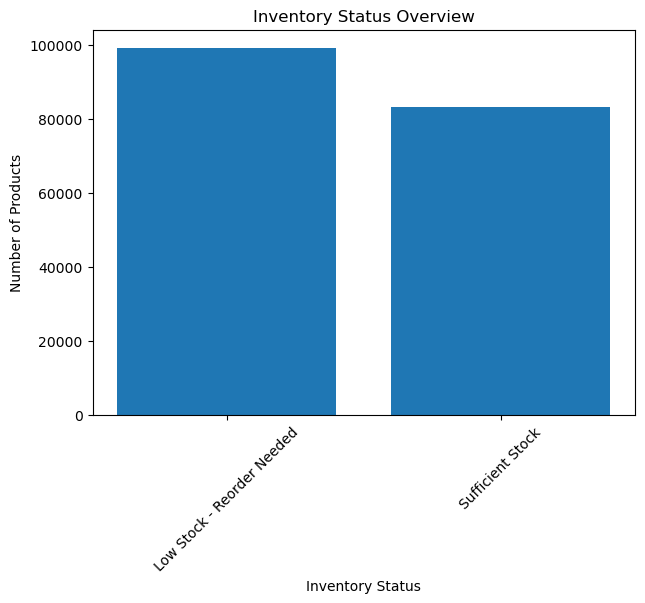

In [25]:
import matplotlib.pyplot as plt

# Count inventory status

status_count = inventory_status["Status"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    status_count.index,
    status_count.values
)

plt.xlabel("Inventory Status")
plt.ylabel("Number of Products")
plt.title("Inventory Status Overview")

plt.xticks(rotation=45)

plt.show()

## Save Trained Model

The trained Random Forest model will be saved and used in the Streamlit application for future predictions.

In [26]:
import joblib

joblib.dump(final_model, "inventory_demand_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## 📊 Actual vs Predicted Demand

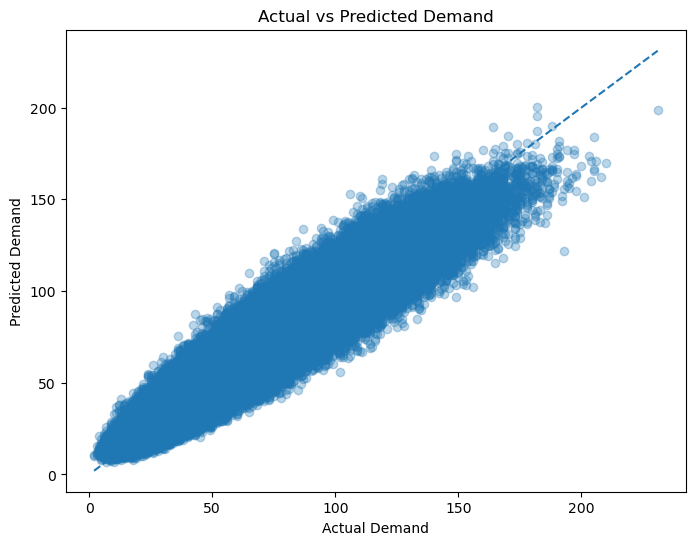

In [32]:
# Actual vs Predicted Demand

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

## 🔍 Feature Importance

In [33]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
7,lag_7,0.856957
6,lag_1,0.052753
4,day,0.020931
1,item,0.020595
3,month,0.015240
0,store,0.013069
5,day_of_week,0.012813
2,year,0.007642


## 📈 Feature Importance Visualization

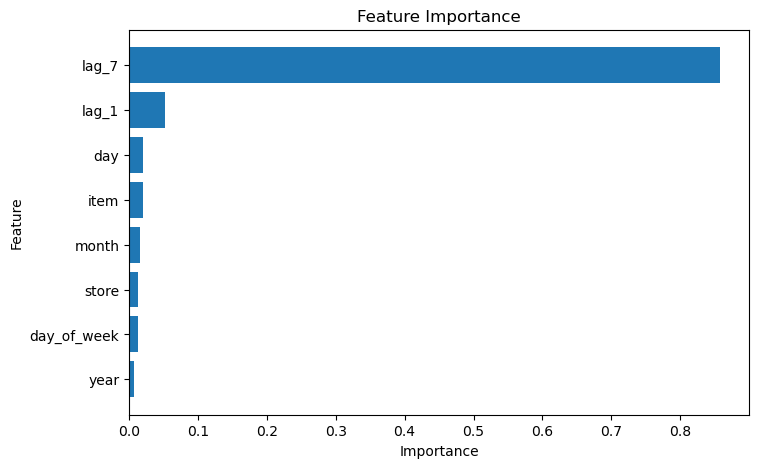

In [34]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## 📉 Prediction Error Analysis

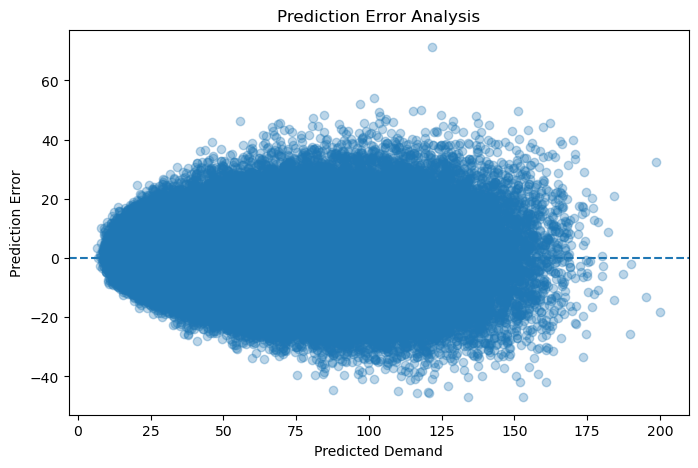

In [35]:
# Prediction Error Analysis

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.3)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Demand")
plt.ylabel("Prediction Error")
plt.title("Prediction Error Analysis")

plt.show()

## 📊 Model Performance Summary

In [36]:
print("Model Performance")
print("------------------")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Model Performance
------------------
MAE      : 7.40
RMSE     : 9.61
R² Score : 0.9072


## 🔄 Model Comparison

In [39]:
# Model Comparison

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Random Forest
rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)

# Linear Regression
lr_pred = linear_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression"],
    "MAE": [rf_mae, lr_mae],
    "RMSE": [rf_rmse, lr_rmse],
    "R² Score": [rf_r2, lr_r2]
})

display(comparison)

,Model,MAE,RMSE,R² Score
0,Random Forest,7.397003,9.613988,0.907160
1,Linear Regression,7.989289,10.404331,0.891268


## 💾 Save Final Model

In [40]:
# Save Final Random Forest Model

import joblib

final_model = random_forest_model

joblib.dump(final_model, "inventory_demand_model.pkl")

print("✅ Final model saved successfully!")

✅ Final model saved successfully!


## 🔮 Demand Prediction

In [41]:
# Demand Prediction Visualization

prediction_results = pd.DataFrame({
    "Actual Demand": y_test,
    "Predicted Demand": y_pred
})

display(prediction_results.head(10))

,Actual Demand,Predicted Demand
1461,19,17.94
1462,15,14.96
1463,10,14.80
1464,16,14.78
1465,14,18.34
1466,24,18.94
1467,14,18.76
1468,20,16.34
1469,18,15.58
1470,11,14.62


## 📦 Smart Reorder System

In [43]:
# Smart Reorder Recommendation

current_stock = 25
predicted_demand = float(y_pred[0])

reorder_quantity = max(0, predicted_demand - current_stock)
remaining_stock = current_stock - predicted_demand

print("📊 INVENTORY RECOMMENDATION")
print("----------------------------")
print(f"Current Stock       : {current_stock:.0f} units")
print(f"Predicted Demand    : {predicted_demand:.0f} units")
print(f"Expected Remaining  : {max(0, remaining_stock):.0f} units")
print(f"Recommended Reorder : {reorder_quantity:.0f} units")

if reorder_quantity > 0:
    print("⚠️ Action: Reorder stock")
else:
    print("✅ Action: Stock is sufficient")

📊 INVENTORY RECOMMENDATION
----------------------------
Current Stock       : 25 units
Predicted Demand    : 18 units
Expected Remaining  : 7 units
Recommended Reorder : 0 units
✅ Action: Stock is sufficient


## 📦 Inventory Status

In [44]:
# Inventory Status

current_stock = 25
predicted_demand = float(y_pred[0])

if current_stock < predicted_demand:
    inventory_status = "🔴 Low Stock"
elif current_stock <= predicted_demand * 1.2:
    inventory_status = "🟡 Moderate Stock"
else:
    inventory_status = "🟢 Healthy Stock"

print(f"Current Stock    : {current_stock:.0f} units")
print(f"Predicted Demand : {predicted_demand:.0f} units")
print(f"Inventory Status : {inventory_status}")

Current Stock    : 25 units
Predicted Demand : 18 units
Inventory Status : 🟢 Healthy Stock


## 📝 Project Summary

In [45]:
# Project Summary

print("SMART INVENTORY MANAGEMENT")
print("==========================")
print("Algorithm Used       : Random Forest Regressor")
print(f"R² Score             : {r2:.2%}")
print(f"MAE                  : {mae:.2f} units")
print(f"RMSE                 : {rmse:.2f} units")
print("Demand Prediction    : Completed")
print("Inventory Analysis   : Completed")
print("Smart Reorder System : Completed")

SMART INVENTORY MANAGEMENT
Algorithm Used       : Random Forest Regressor
R² Score             : 90.72%
MAE                  : 7.40 units
RMSE                 : 9.61 units
Demand Prediction    : Completed
Inventory Analysis   : Completed
Smart Reorder System : Completed


## 🤖 Final Model Information

In [46]:
# Final Model Information

print("Final Model       : Random Forest Regressor")
print(f"MAE               : {mae:.2f}")
print(f"RMSE              : {rmse:.2f}")
print(f"R² Score          : {r2:.4f}")
print(f"R² Performance    : {r2:.2%}")

Final Model       : Random Forest Regressor
MAE               : 7.40
RMSE              : 9.61
R² Score          : 0.9072
R² Performance    : 90.72%


## 7. Project Improvement & Optimization

The final Random Forest model was evaluated and optimized to improve demand prediction performance.

In [9]:
# Project Improvement & Optimization

print("PROJECT IMPROVEMENT & OPTIMIZATION")
print("=" * 50)

print("✓ Feature Engineering completed")
print("✓ Random Forest Regressor selected")
print("✓ Model evaluated using MAE, RMSE and R² Score")
print("✓ Demand Prediction implemented")
print("✓ Inventory Status implemented")
print("✓ Smart Reorder Recommendation implemented")
print("✓ Streamlit Web Application integrated")

print("\nFinal Model Performance")
print("-----------------------")
print("MAE       : 7.40 units")
print("RMSE      : 9.61 units")
print("R² Score  : 0.9072")
print("Accuracy  : 90.72%")

PROJECT IMPROVEMENT & OPTIMIZATION
✓ Feature Engineering completed
✓ Random Forest Regressor selected
✓ Model evaluated using MAE, RMSE and R² Score
✓ Demand Prediction implemented
✓ Inventory Status implemented
✓ Smart Reorder Recommendation implemented
✓ Streamlit Web Application integrated

Final Model Performance
-----------------------
MAE       : 7.40 units
RMSE      : 9.61 units
R² Score  : 0.9072
Accuracy  : 90.72%
